# Dimensionamento das 3 Alavancas de Receita

**Pergunta executiva:** *"Quais são as alavancas mais efetivas para aumentar a receita nos próximos 6 meses?"*

Este notebook é a memória de cálculo do One-Pager: para cada alavanca, mostra a evidência observada no DW, a premissa assumida e a projeção resultante.

**Duas escolhas que valem registro, porque mudam o resultado:**

- **Todo cálculo usa o último semestre completo (2018-S1) como recorte**, tanto a base de comparação (R$ 5,51M de GMV) quanto as bases de cada projeção. A receita cresce forte ao longo da série, então dividir os 24 meses por 4 embutiria a fase de rampa da plataforma. Se a base de comparação é o run-rate, as bases de cálculo também precisam ser: misturar as duas coisas compararia períodos diferentes e subdimensionaria as alavancas.
- **Nenhuma alavanca é dimensionada por retenção.** Testamos essa hipótese na Alavanca 2 (seção 3) e o efeito encontrado é pequeno demais para sustentar uma projeção de receita.

In [1]:
import os
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

try:
    from IPython.display import display
except ImportError:
    display = print

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['font.size'] = 11
pd.set_option('display.float_format', lambda x: '%.2f' % x)

warnings.filterwarnings('ignore')

# Conexão com o banco de dados analítico DuckDB
db_path = '../data/processed/olist.duckdb'
if not os.path.exists(db_path):
    db_path = 'data/processed/olist.duckdb'

conn = duckdb.connect(db_path, read_only=True)
print("Conexão com o banco de dados estabelecida com sucesso!")

Conexão com o banco de dados estabelecida com sucesso!


---
## 1. Linha de base: por que o run-rate e não a média

Antes de projetar qualquer coisa, precisamos decidir contra o que comparar. A série semestral abaixo mostra por que a média histórica seria um denominador enganoso.

In [2]:
query_semestres = """
SELECT
    YEAR(p.purchase_timestamp) AS ano,
    CASE WHEN MONTH(p.purchase_timestamp) <= 6 THEN 'S1' ELSE 'S2' END AS semestre,
    COUNT(DISTINCT p.order_id) AS pedidos,
    ROUND(SUM(i.price), 2) AS gmv
FROM fato_pedidos p
JOIN fato_itens i ON p.order_id = i.order_id
WHERE p.order_status = 'delivered'
GROUP BY 1, 2
ORDER BY 1, 2
"""
df_sem = conn.execute(query_semestres).df()
display(df_sem)

# 2018-S2 fica de fora: a base termina em 03/09/2018, é um semestre truncado.
BASE_SEMESTRAL = float(df_sem.query("ano == 2018 and semestre == 'S1'")['gmv'].iloc[0])
PEDIDOS_SEMESTRE = int(df_sem.query("ano == 2018 and semestre == 'S1'")['pedidos'].iloc[0])

# Recorte usado em TODAS as bases de projeção deste notebook, não só na comparação.
FILTRO_RUN_RATE = "YEAR(p.purchase_timestamp) = 2018 AND MONTH(p.purchase_timestamp) <= 6"

historico = conn.execute("""
    SELECT ROUND(SUM(i.price), 2) AS gmv,
           COUNT(DISTINCT p.order_id) AS pedidos,
           ROUND(SUM(i.price) / COUNT(DISTINCT p.order_id), 2) AS ticket
    FROM fato_pedidos p JOIN fato_itens i ON p.order_id = i.order_id
    WHERE p.order_status = 'delivered'
""").df()
TICKET_MEDIO = float(historico['ticket'].iloc[0])

print(f"GMV histórico (24 meses, entregues): R$ {historico['gmv'].iloc[0]:,.2f} em {historico['pedidos'].iloc[0]:,} pedidos")
print(f"Ticket médio por pedido:             R$ {TICKET_MEDIO:,.2f}")
print()
print(f"Média histórica / 4 semestres:       R$ {historico['gmv'].iloc[0] / 4:,.2f}   <- denominador enganoso")
print(f"Run-rate 2018-S1 (base adotada):     R$ {BASE_SEMESTRAL:,.2f}   em {PEDIDOS_SEMESTRE:,} pedidos")
print(f"Diferença entre os dois:             {BASE_SEMESTRAL / (historico['gmv'].iloc[0] / 4) - 1:+.1%}")

,ano,semestre,pedidos,gmv
0,2016,S2,267,40470.98
1,2017,S1,13933,1957151.91
2,2017,S2,29495,4005750.10
3,2018,S1,40273,5511595.02
4,2018,S2,12510,1706530.10


GMV histórico (24 meses, entregues): R$ 13,221,498.11 em 96,478 pedidos
Ticket médio por pedido:             R$ 137.04

Média histórica / 4 semestres:       R$ 3,305,374.53   <- denominador enganoso
Run-rate 2018-S1 (base adotada):     R$ 5,511,595.02   em 40,273 pedidos
Diferença entre os dois:             +66.7%


---
## 2. Alavanca 1: Parcelamento sem juros em até 10x

**Evidência.** O valor médio da transação cresce com o número de parcelas: quem paga à vista gasta em média R$ 95,83, e quem parcela em 10x gasta R$ 413,69 (4,3 vezes mais). Cartão de crédito responde por 78,4% do valor transacionado na plataforma.

**Premissa.** Essa relação é observacional, o dataset não tem teste A/B nem mudança de política de parcelamento no período, então não dá para provar causalidade com este dado. É plausível que oferecer a condição desloque parte da demanda para itens de maior valor, mas a leitura inversa também é razoável (parcela-se em 10x porque a compra já é cara). Por segurança, a projeção usa um incremento mais conservador (R$ 250) que o diferencial observado (R$ 317,86), e o plano de ação condiciona a escala a um teste A/B nos primeiros 60 dias.

,parcelas,pedidos,valor_medio
0,1,25265,95.83
1,2,12329,126.90
2,3,10374,142.29
3,4,7046,163.85
4,5,5204,182.59
5,6,3894,209.69
6,7,1617,187.61
7,8,4224,307.22
8,9,638,204.21
9,10,5279,413.69


1x: R$ 95.83  |  10x: R$ 413.69  |  múltiplo: 4.3x  |  diferencial: R$ 317.86


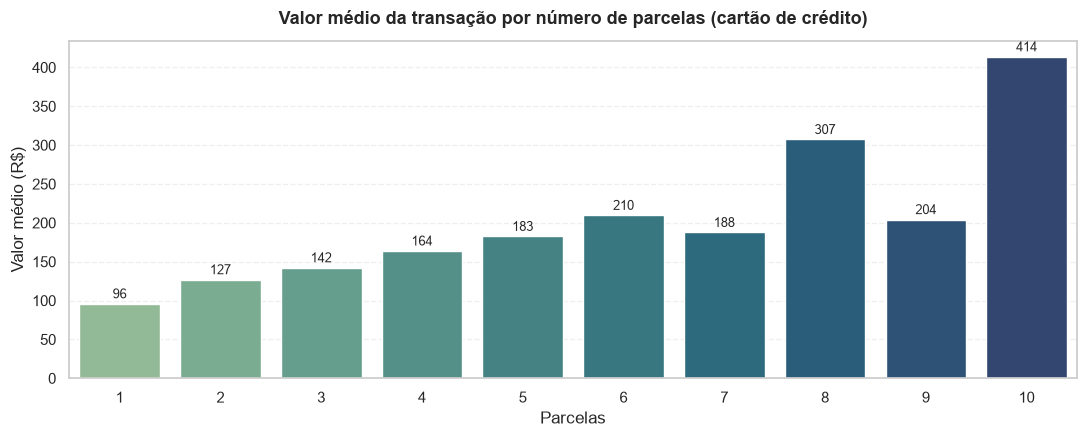

In [3]:
# A tabela abaixo usa os 24 meses de propósito: o objetivo aqui é medir a RELAÇÃO entre
# parcelas e valor, e mais observações dão uma média mais estável. O recorte de run-rate
# entra na célula de dimensionamento, onde o que importa é o VOLUME de um semestre.
query_installments = """
SELECT
    payment_installments AS parcelas,
    COUNT(DISTINCT order_id) AS pedidos,
    ROUND(AVG(payment_value), 2) AS valor_medio
FROM fato_pagamentos
WHERE payment_type = 'credit_card' AND payment_installments BETWEEN 1 AND 12
GROUP BY 1
ORDER BY 1
"""
df_inst = conn.execute(query_installments).df()
display(df_inst)

v1x = float(df_inst.query("parcelas == 1")['valor_medio'].iloc[0])
v10x = float(df_inst.query("parcelas == 10")['valor_medio'].iloc[0])
print(f"1x: R$ {v1x:,.2f}  |  10x: R$ {v10x:,.2f}  |  múltiplo: {v10x / v1x:.1f}x  |  diferencial: R$ {v10x - v1x:,.2f}")

# A relação não é monotônica (7x e 9x quebram a sequência) -- o gráfico deixa isso visível
# em vez de descrever como "correlação acentuada", o que seria forte demais para o dado.
plt.figure(figsize=(11, 4.5))
ax = sns.barplot(data=df_inst[df_inst['parcelas'] <= 10], x='parcelas', y='valor_medio', palette='crest')
plt.title('Valor médio da transação por número de parcelas (cartão de crédito)',
          fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Parcelas')
plt.ylabel('Valor médio (R$)')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9, xytext=(0, 2), textcoords='offset points')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Ação e dimensionamento

**Ação.** Subsidiar a taxa de antecipação de recebíveis (~3,0% a 3,5%) junto às adquirentes para habilitar 10x sem juros em itens acima de R$ 150, começando pelas categorias de maior preço unitário (célula seguinte).

**Base de conversão.** O universo a ser deslocado são os pedidos pagos à vista no cartão **em 2018-S1**, mesmo recorte da base de comparação. O volume à vista acompanha a curva de crescimento da plataforma (3.210 no 2017-S1, 11.567 no 2018-S1), então usar a média dos 24 meses subdimensionaria a alavanca pela metade.

In [4]:
# Categorias de maior preço unitário -- onde o parcelamento estendido faz diferença.
query_high_ticket = """
SELECT
    p.category_name AS categoria,
    COUNT(DISTINCT i.order_id) AS pedidos,
    ROUND(AVG(i.price), 2) AS preco_medio_item,
    ROUND(SUM(i.price), 2) AS gmv
FROM fato_itens i
JOIN dim_produto p ON i.product_id = p.product_id
GROUP BY 1
HAVING COUNT(DISTINCT i.order_id) > 500
ORDER BY preco_medio_item DESC
LIMIT 6
"""
display(conn.execute(query_high_ticket).df())

# --- Dimensionamento ---
# Base de conversão no run-rate: pedidos à vista no cartão em 2018-S1.
base_1x_semestre = conn.execute(f"""
    SELECT COUNT(DISTINCT pg.order_id)
    FROM fato_pedidos p
    JOIN fato_pagamentos pg ON p.order_id = pg.order_id
    WHERE pg.payment_type = 'credit_card'
      AND pg.payment_installments = 1
      AND {FILTRO_RUN_RATE}
""").fetchone()[0]

# Premissas de negócio, deliberadamente conservadoras: sem um A/B que meça o deslocamento
# real, preferimos subdimensionar e deixar o restante como upside da validação.
TAXA_CONVERSAO = (0.08, 0.12)   # fração dos compradores à vista que sobe de ticket
INCREMENTO_POR_PEDIDO = 250.00  # abaixo do diferencial observado de R$ 317,86

pedidos_1x_hist = int(df_inst.query("parcelas == 1")['pedidos'].iloc[0])
print(f"Pedidos à vista no cartão (24 meses):   {pedidos_1x_hist:,}")
print(f"Pedidos à vista no cartão (2018-S1):    {base_1x_semestre:,}   <- base usada")
print()

A1_MIN = base_1x_semestre * TAXA_CONVERSAO[0] * INCREMENTO_POR_PEDIDO
A1_MAX = base_1x_semestre * TAXA_CONVERSAO[1] * INCREMENTO_POR_PEDIDO
for rotulo, taxa, valor in [("Conservador", TAXA_CONVERSAO[0], A1_MIN), ("Otimista", TAXA_CONVERSAO[1], A1_MAX)]:
    convertidos = base_1x_semestre * taxa
    print(f"{rotulo:12} {taxa:.0%} de {base_1x_semestre:,} = {convertidos:,.0f} pedidos "
          f"x R$ {INCREMENTO_POR_PEDIDO:.0f} = R$ {valor:,.0f}")

print(f"\nAlavanca 1: +R$ {A1_MIN:,.0f} a +R$ {A1_MAX:,.0f} no semestre "
      f"({A1_MIN / BASE_SEMESTRAL:+.1%} a {A1_MAX / BASE_SEMESTRAL:+.1%} sobre a base)")

,categoria,pedidos,preco_medio_item,gmv
0,musical_instruments,620,280.70,187788.44
1,small_appliances,622,280.04,187907.26
2,watches_gifts,5604,200.70,1198185.21
3,cool_stuff,3617,164.24,620835.39
4,office_furniture,1272,161.88,273580.70
5,construction_tools_construction,746,155.93,144550.19


Pedidos à vista no cartão (24 meses):   25,265
Pedidos à vista no cartão (2018-S1):    11,567   <- base usada

Conservador  8% de 11,567 = 925 pedidos x R$ 250 = R$ 231,340
Otimista     12% de 11,567 = 1,388 pedidos x R$ 250 = R$ 347,010

Alavanca 1: +R$ 231,340 a +R$ 347,010 no semestre (+4.2% a +6.3% sobre a base)


---
## 3. Alavanca 2: Curadoria de sortimento por causa-raiz de detração

Antes de desenhar esta alavanca, testamos se dava para dimensioná-la por **retenção**: clientes que tiveram entrega atrasada recomprariam menos, e corrigir os atrasos preservaria receita futura. A célula abaixo mostra por que essa hipótese não se sustenta.

In [5]:
# --- O atraso na entrega reduz a recompra? ---
query_recompra_atraso = """
WITH primeiro AS (
    SELECT c.customer_unique_id,
           p.atrasou,
           ROW_NUMBER() OVER (PARTITION BY c.customer_unique_id ORDER BY p.purchase_timestamp) AS rn
    FROM fato_pedidos p
    JOIN dim_cliente c ON p.customer_id = c.customer_id
    WHERE p.order_status = 'delivered' AND p.atrasou IS NOT NULL
),
totais AS (
    SELECT c.customer_unique_id, COUNT(DISTINCT p.order_id) AS n_pedidos
    FROM fato_pedidos p
    JOIN dim_cliente c ON p.customer_id = c.customer_id
    WHERE p.order_status = 'delivered'
    GROUP BY 1
)
SELECT CASE WHEN pr.atrasou THEN 'Com atraso' ELSE 'No prazo' END AS status_1a_entrega,
       COUNT(*) AS clientes,
       SUM(CASE WHEN t.n_pedidos > 1 THEN 1 ELSE 0 END) AS recompraram,
       ROUND(100.0 * SUM(CASE WHEN t.n_pedidos > 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS taxa_recompra_pct
FROM primeiro pr JOIN totais t USING (customer_unique_id)
WHERE pr.rn = 1
GROUP BY 1 ORDER BY 1
"""
df_atraso = conn.execute(query_recompra_atraso).df()
display(df_atraso)

atrasados_semestre = conn.execute(f"""
    SELECT COUNT(*) FROM fato_pedidos p
    WHERE p.order_status = 'delivered' AND p.atrasou AND {FILTRO_RUN_RATE}
""").fetchone()[0]

delta_pp = df_atraso.taxa_recompra_pct.max() - df_atraso.taxa_recompra_pct.min()
print(f"Diferença de recompra entre os dois grupos: {delta_pp:.2f} ponto percentual.")
print(f"No limite: mesmo zerando TODOS os {atrasados_semestre:,} atrasos de um semestre, o efeito "
      f"preserva uns {atrasados_semestre * delta_pp / 100:.0f} clientes -- pequeno demais para virar alavanca.")

# --- A nota da avaliação prevê recompra? ---
query_recompra_nota = """
WITH primeiro AS (
    SELECT c.customer_unique_id, p.review_score,
           ROW_NUMBER() OVER (PARTITION BY c.customer_unique_id ORDER BY p.purchase_timestamp) AS rn
    FROM fato_pedidos p
    JOIN dim_cliente c ON p.customer_id = c.customer_id
    WHERE p.order_status = 'delivered' AND p.review_score IS NOT NULL
),
totais AS (
    SELECT c.customer_unique_id, COUNT(DISTINCT p.order_id) AS n_pedidos
    FROM fato_pedidos p
    JOIN dim_cliente c ON p.customer_id = c.customer_id
    WHERE p.order_status = 'delivered'
    GROUP BY 1
)
SELECT pr.review_score AS nota_1o_pedido,
       COUNT(*) AS clientes,
       ROUND(100.0 * SUM(CASE WHEN t.n_pedidos > 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS taxa_recompra_pct
FROM primeiro pr JOIN totais t USING (customer_unique_id)
WHERE pr.rn = 1
GROUP BY 1 ORDER BY 1
"""
df_nota = conn.execute(query_recompra_nota).df()
display(df_nota)
print(f"Amplitude entre a melhor e a pior nota: "
      f"{df_nota.taxa_recompra_pct.max() - df_nota.taxa_recompra_pct.min():.2f} p.p. "
      f"-- nota 4 recompra menos que nota 1. Satisfação não prevê recompra nesta base.")

print("\nCom 97% de compradores únicos e diferenças de recompra desse tamanho, nenhuma alavanca deste case é dimensionada por retenção.")

,status_1a_entrega,clientes,recompraram,taxa_recompra_pct
0,Com atraso,7603,190.00,2.50
1,No prazo,85747,2611.00,3.05


Diferença de recompra entre os dois grupos: 0.55 ponto percentual.
No limite: mesmo zerando TODOS os 4,008 atrasos de um semestre, o efeito preserva uns 22 clientes -- pequeno demais para virar alavanca.


,nota_1o_pedido,clientes,taxa_recompra_pct
0,1,9086,2.86
1,2,2833,2.75
2,3,7668,2.96
3,4,18366,2.78
4,5,54802,3.13


Amplitude entre a melhor e a pior nota: 0.38 p.p. -- nota 4 recompra menos que nota 1. Satisfação não prevê recompra nesta base.

Com 97% de compradores únicos e diferenças de recompra desse tamanho, nenhuma alavanca deste case é dimensionada por retenção.


In [6]:
# --- Onde a detração realmente acontece ---
query_detracao = """
SELECT
    CASE WHEN p.atrasou
         THEN 'Entrega atrasada' ELSE 'Entrega no prazo' END AS pontualidade,
    COUNT(*) AS pedidos,
    SUM(CASE WHEN p.review_score <= 2 THEN 1 ELSE 0 END) AS detratores,
    ROUND(100.0 * SUM(CASE WHEN p.review_score <= 2 THEN 1 ELSE 0 END) / COUNT(*), 1) AS taxa_detracao_pct
FROM fato_pedidos p
WHERE p.order_status = 'delivered'
  AND p.atrasou IS NOT NULL
  AND p.review_score IS NOT NULL
GROUP BY 1 ORDER BY 1
"""
df_det = conn.execute(query_detracao).df()
display(df_det)

det_total = int(df_det.detratores.sum())
det_no_prazo = int(df_det.query("pontualidade == 'Entrega no prazo'")['detratores'].iloc[0])
print(f"{det_no_prazo:,} de {det_total:,} detratores ({det_no_prazo / det_total:.0%}) receberam NO PRAZO "
      f"e mesmo assim deram nota <= 2.")
print("O atraso explica só o terço restante -- e é a única dimensão que a métrica logística enxerga hoje.")

# GMV exposto a falha não-logística, no mesmo recorte de run-rate das demais alavancas.
GMV_EXPOSTO_SEMESTRE = conn.execute(f"""
    SELECT ROUND(SUM(i.price), 2)
    FROM fato_pedidos p JOIN fato_itens i ON p.order_id = i.order_id
    WHERE p.order_status = 'delivered'
      AND p.review_score <= 2
      AND NOT p.atrasou
      AND {FILTRO_RUN_RATE}
""").fetchone()[0]

print(f"\nGMV exposto a falha não-logística (2018-S1): R$ {GMV_EXPOSTO_SEMESTRE:,.2f}")

print("\nCategorias com mais detração em entregas pontuais:")
display(conn.execute("""
    SELECT pr.category_name AS categoria,
           COUNT(DISTINCT p.order_id) AS detratores,
           ROUND(SUM(i.price), 2) AS gmv_exposto
    FROM fato_pedidos p
    JOIN fato_itens i ON p.order_id = i.order_id
    JOIN dim_produto pr ON i.product_id = pr.product_id
    WHERE p.order_status = 'delivered' AND p.review_score <= 2
      AND NOT p.atrasou
    GROUP BY 1 ORDER BY detratores DESC LIMIT 6
""").df())

,pontualidade,pedidos,detratores,taxa_detracao_pct
0,Entrega atrasada,7661,4141.00,54.10
1,Entrega no prazo,88163,8127.00,9.20


8,127 de 12,268 detratores (66%) receberam NO PRAZO e mesmo assim deram nota <= 2.
O atraso explica só o terço restante -- e é a única dimensão que a métrica logística enxerga hoje.

GMV exposto a falha não-logística (2018-S1): R$ 583,214.01

Categorias com mais detração em entregas pontuais:


,categoria,detratores,gmv_exposto
0,bed_bath_table,1029,130435.91
1,computers_accessories,680,116673.54
2,furniture_decor,672,87612.27
3,health_beauty,588,85073.98
4,sports_leisure,529,83760.16
5,watches_gifts,488,94856.55


### Onde o NLP entra

O corte por pontualidade diz *quanto* do problema é não-logístico, mas não diz *o quê*. A classificação semântica das avaliações (`fato_reviews_classificados`) preenche essa lacuna, separando falha controlável pelo seller (item faltante, produto divergente, defeito) de ruído ou insatisfação genérica.

### Ação e dimensionamento

**Ação.** Painel de causa-raiz por seller alimentado pela classificação de NLP, com remediação de 30 dias para reincidentes em falha controlável.

**Premissa declarada.** O dataset não tem dado de devolução, custo de logística reversa nem funil de conversão, então o mecanismo de receita não é observável direto. Assumimos que **30% do GMV exposto é recuperável** ao reduzir a taxa de detração em entregas pontuais de 9,2% para ~6,5%. É premissa de negócio, não achado.

In [7]:
# A tabela abaixo é produzida por src/ia/classify_reviews.py. Registros com is_fallback=True
# são lotes em que a chamada ao modelo falhou -- ficam fora do percentual para não inflar
# artificialmente a categoria mais comum.
try:
    df_ia = conn.execute("""
        SELECT categoria_primaria, severidade, is_fallback
        FROM fato_reviews_classificados
    """).df()
except Exception:
    df_ia = conn.execute("""
        SELECT categoria_primaria, severidade,
               motivo_especifico LIKE '%fallback%' AS is_fallback
        FROM fato_reviews_classificados
    """).df()

n_total, n_fallback = len(df_ia), int(df_ia.is_fallback.sum())
print(f"Registros classificados: {n_total}  |  não classificados (fallback): {n_fallback}")

if n_fallback / max(n_total, 1) > 0.05:
    print("\n>>> ATENÇÃO: muitos lotes falharam na classificação.")
    print(">>> Rode `python src/ia/classify_reviews.py` novamente antes de citar percentuais.")
else:
    validos = df_ia[~df_ia.is_fallback]
    dist = (validos.categoria_primaria.value_counts(normalize=True) * 100).round(1)
    display(dist.rename('pct_das_queixas').to_frame())

    universo = conn.execute("""
        SELECT COUNT(*) FROM fato_pedidos
        WHERE review_score <= 2 AND review_comment_message IS NOT NULL
          AND TRIM(review_comment_message) != ''
    """).fetchone()[0]
    n = len(validos)
    print(f"\nAmostra de {n} avaliações sobre um universo de {universo:,} detratores com texto ({n / universo:.1%}).")
    print("Amostra pequena: leia os percentuais acima como ordem de grandeza, não como número exato.")

# --- Dimensionamento da Alavanca 2 ---
TAXA_RECUPERACAO = 0.30  # premissa: fração do GMV exposto recuperável com remediação
A2 = GMV_EXPOSTO_SEMESTRE * TAXA_RECUPERACAO

print(f"\nGMV exposto (2018-S1):     R$ {GMV_EXPOSTO_SEMESTRE:,.0f}")
print(f"Premissa de recuperação:    {TAXA_RECUPERACAO:.0%}")
print(f"Alavanca 2: +R$ {A2:,.0f} no semestre ({A2 / BASE_SEMESTRAL:+.1%} sobre a base)")

Registros classificados: 40  |  não classificados (fallback): 0


,pct_das_queixas
categoria_primaria,
logistica_atraso_extravio,45.00
qualidade_avaria_falsificacao,20.00
atendimento_sac_estorno,15.00
produto_divergente_incompleto,15.00
problemas_entrega_frete,5.00



Amostra de 40 avaliações sobre um universo de 10,493 detratores com texto (0.4%).
Amostra pequena: leia os percentuais acima como ordem de grandeza, não como número exato.

GMV exposto (2018-S1):     R$ 583,214
Premissa de recuperação:    30%
Alavanca 2: +R$ 174,964 no semestre (+3.2% sobre a base)


---
## 4. Alavanca 3: Ativação de oferta local no Norte e Nordeste

**O desequilíbrio.** N/NE concentra 11,4% dos compradores e 1,97% dos vendedores. Mais de 10 mil pedidos da região são atendidos por sellers de outras UFs, e 7.662 saem só de São Paulo.

**Já existe prova de conceito.** Os 61 sellers locais que operam hoje entregam com frete 29% menor e prazo 25% mais curto que os remotos — a célula abaixo compara os dois grupos. O ganho é real, mas menor do que a intuição sugere: estoque local atenua a fricção logística da região, não a elimina.

**A restrição de desenho.** Mais da metade da base cadastrada (1.686 de 3.056 sellers com venda) vendeu menos de 10 itens em dois anos e responde por 8,1% do GMV. Cadastrar seller não é o gargalo, ativar é. Por isso dimensionamos a alavanca sobre sellers *ativados*, usando a taxa de ativação observada na própria base (45%), e a meta operacional passa a ser GMV por seller no 90º dia, não volume de cadastro.

In [8]:
NNE = "('MA','PI','CE','RN','PB','PE','AL','SE','BA','AM','PA','AC','RR','RO','AP','TO')"

# --- 1. O desequilíbrio entre demanda e oferta ---
query_desbalanco = f"""
WITH demanda AS (
    SELECT COUNT(DISTINCT CASE WHEN c.state IN {NNE} THEN c.customer_unique_id END) AS clientes_nne,
           COUNT(DISTINCT c.customer_unique_id) AS clientes_total
    FROM dim_cliente c
),
oferta AS (
    SELECT COUNT(CASE WHEN state IN {NNE} THEN 1 END) AS sellers_nne,
           COUNT(*) AS sellers_total
    FROM dim_vendedor
)
SELECT d.clientes_nne, ROUND(100.0 * d.clientes_nne / d.clientes_total, 2) AS pct_clientes,
       o.sellers_nne, ROUND(100.0 * o.sellers_nne / o.sellers_total, 2) AS pct_sellers
FROM demanda d CROSS JOIN oferta o
"""
display(conn.execute(query_desbalanco).df())

# --- 2. Prova de conceito: seller local vs seller remoto atendendo o N/NE ---
query_origem = f"""
SELECT
    CASE WHEN v.state IN {NNE} THEN 'Seller local (N/NE)' ELSE 'Seller de outra UF' END AS origem,
    COUNT(DISTINCT p.order_id) AS pedidos,
    ROUND(AVG(i.freight_value), 2) AS frete_medio,
    ROUND(AVG(p.prazo_entrega_dias), 1) AS prazo_dias
FROM fato_pedidos p
JOIN dim_cliente c ON p.customer_id = c.customer_id
JOIN fato_itens i ON p.order_id = i.order_id
JOIN dim_vendedor v ON i.seller_id = v.seller_id
WHERE c.state IN {NNE} AND p.order_status = 'delivered' AND p.atrasou IS NOT NULL
GROUP BY 1 ORDER BY 1
"""
df_origem = conn.execute(query_origem).df()
display(df_origem)

remoto = df_origem.query("origem == 'Seller de outra UF'").iloc[0]
local = df_origem.query("origem == 'Seller local (N/NE)'").iloc[0]
print(f"Frete: R$ {remoto.frete_medio:.2f} -> R$ {local.frete_medio:.2f} "
      f"({local.frete_medio / remoto.frete_medio - 1:+.0%})")
print(f"Prazo: {remoto.prazo_dias:.1f} -> {local.prazo_dias:.1f} dias "
      f"({local.prazo_dias / remoto.prazo_dias - 1:+.0%})")

# --- 3. A cauda: por que a meta é ativação e não cadastro ---
query_ativacao = """
SELECT faixa, COUNT(*) AS sellers, ROUND(SUM(gmv), 2) AS gmv,
       ROUND(100.0 * SUM(gmv) / SUM(SUM(gmv)) OVER (), 1) AS pct_gmv
FROM (
    SELECT seller_id, COUNT(*) AS itens, SUM(price) AS gmv,
           CASE WHEN COUNT(*) < 10  THEN '1. menos de 10 itens'
                WHEN COUNT(*) < 50  THEN '2. de 10 a 49'
                WHEN COUNT(*) < 200 THEN '3. de 50 a 199'
                ELSE '4. 200 itens ou mais' END AS faixa
    FROM fato_itens GROUP BY 1
)
GROUP BY 1 ORDER BY 1
"""
df_ativacao = conn.execute(query_ativacao).df()
display(df_ativacao)

inativos = int(df_ativacao.iloc[0].sellers)
sellers_total = int(df_ativacao.sellers.sum())
TAXA_ATIVACAO = 1 - inativos / sellers_total
print(f"{inativos:,} de {sellers_total:,} sellers ({inativos / sellers_total:.0%}) vendeu menos de 10 itens "
      f"e responde por {df_ativacao.iloc[0].pct_gmv:.1f}% do GMV.")
print(f"Taxa de ativação observada na plataforma: {TAXA_ATIVACAO:.0%} -- é a premissa do dimensionamento.")

# --- 4. Dimensionamento ---
# GMV por seller local no run-rate: o que um seller do N/NE faturou em 2018-S1, sobre o
# número de sellers efetivamente ativos no período -- mesmo recorte das outras alavancas.
gmv_seller_semestre = conn.execute(f"""
    SELECT ROUND(SUM(i.price) / COUNT(DISTINCT v.seller_id), 2)
    FROM fato_pedidos p
    JOIN fato_itens i ON p.order_id = i.order_id
    JOIN dim_vendedor v ON i.seller_id = v.seller_id
    WHERE v.state IN {NNE} AND {FILTRO_RUN_RATE}
""").fetchone()[0]

RECRUTAMENTO = (80, 120)
A3_MIN = RECRUTAMENTO[0] * TAXA_ATIVACAO * gmv_seller_semestre
A3_MAX = RECRUTAMENTO[1] * TAXA_ATIVACAO * gmv_seller_semestre

print(f"\nGMV por seller local em 2018-S1: R$ {gmv_seller_semestre:,.2f}")
for n_sellers, valor in [(RECRUTAMENTO[0], A3_MIN), (RECRUTAMENTO[1], A3_MAX)]:
    print(f"{n_sellers} recrutados x {TAXA_ATIVACAO:.0%} ativação x R$ {gmv_seller_semestre:,.0f} "
          f"= R$ {valor:,.0f}")

print(f"\nAlavanca 3: +R$ {A3_MIN:,.0f} a +R$ {A3_MAX:,.0f} no semestre "
      f"({A3_MIN / BASE_SEMESTRAL:+.1%} a {A3_MAX / BASE_SEMESTRAL:+.1%} sobre a base)")
print("Não projetamos ganho de conversão sobre a demanda N/NE já existente: o frete ~30% menor deve")
print("elevar conversão, mas o dataset não tem funil para medir isso. Fica como upside qualitativo.")

,clientes_nne,pct_clientes,sellers_nne,pct_sellers
0,10933,11.38,61,1.97


,origem,pedidos,frete_medio,prazo_dias
0,Seller de outra UF,10362,33.43,20.50
1,Seller local (N/NE),485,23.90,15.30


Frete: R$ 33.43 -> R$ 23.90 (-29%)
Prazo: 20.5 -> 15.3 dias (-25%)


,faixa,sellers,gmv,pct_gmv
0,1. menos de 10 itens,1686,1089711.57,8.10
1,2. de 10 a 49,904,3061909.53,22.70
2,3. de 50 a 199,363,4064276.56,30.10
3,4. 200 itens ou mais,103,5280510.77,39.10


1,686 de 3,056 sellers (55%) vendeu menos de 10 itens e responde por 8.1% do GMV.
Taxa de ativação observada na plataforma: 45% -- é a premissa do dimensionamento.

GMV por seller local em 2018-S1: R$ 3,438.19
80 recrutados x 45% ativação x R$ 3,438 = R$ 123,307
120 recrutados x 45% ativação x R$ 3,438 = R$ 184,960

Alavanca 3: +R$ 123,307 a +R$ 184,960 no semestre (+2.2% a +3.4% sobre a base)
Não projetamos ganho de conversão sobre a demanda N/NE já existente: o frete ~30% menor deve
elevar conversão, mas o dataset não tem funil para medir isso. Fica como upside qualitativo.


---
## 5. Quadro consolidado

Os três valores abaixo saem das células anteriores, sem número digitado à mão. Numerador e denominador vêm do mesmo período (2018-S1), então os percentuais são comparáveis entre si.

Duas premissas de negócio entram no cálculo e estão declaradas onde são usadas: a conversão de 8% a 12% na Alavanca 1 e a recuperação de 30% do GMV exposto na Alavanca 2. O resto vem do dado.

,alavanca,mecanismo,min,max,pct_min,pct_max
0,1. Parcelamento 10x sem juros,Aumento de ticket,231340.00,347010.00,4.20,6.30
1,2. Curadoria de sortimento (NLP),Recuperação de GMV exposto,174964.20,174964.20,3.17,3.17
2,3. Ativação de sellers no N/NE,Oferta local,123306.81,184960.22,2.24,3.36


Base semestral de referência (2018-S1): R$ 5,511,595
Impacto consolidado:                    +R$ 529,611 a +R$ 706,934
Crescimento sobre a base:               +9.6% a +12.8%
Novo patamar projetado:                 R$ 6,041,206 a R$ 6,218,529


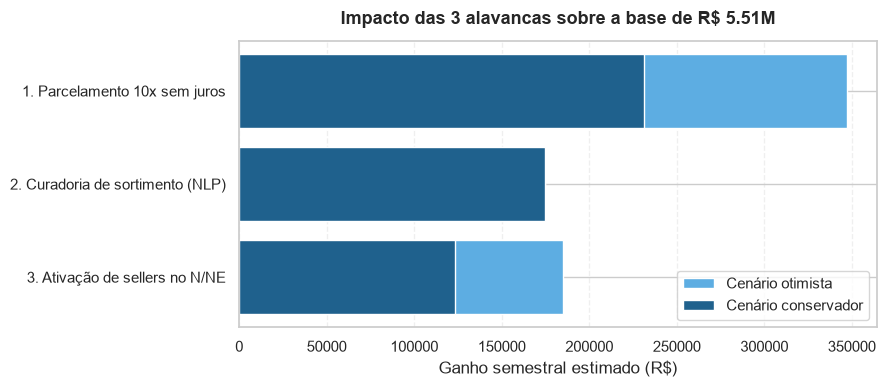

In [9]:
df_consolidado = pd.DataFrame([
    {"alavanca": "1. Parcelamento 10x sem juros", "min": A1_MIN, "max": A1_MAX,
     "mecanismo": "Aumento de ticket"},
    {"alavanca": "2. Curadoria de sortimento (NLP)", "min": A2, "max": A2,
     "mecanismo": "Recuperação de GMV exposto"},
    {"alavanca": "3. Ativação de sellers no N/NE", "min": A3_MIN, "max": A3_MAX,
     "mecanismo": "Oferta local"},
])
df_consolidado["pct_min"] = df_consolidado["min"] / BASE_SEMESTRAL * 100
df_consolidado["pct_max"] = df_consolidado["max"] / BASE_SEMESTRAL * 100

total_min, total_max = df_consolidado["min"].sum(), df_consolidado["max"].sum()

display(df_consolidado[["alavanca", "mecanismo", "min", "max", "pct_min", "pct_max"]])

print(f"Base semestral de referência (2018-S1): R$ {BASE_SEMESTRAL:,.0f}")
print(f"Impacto consolidado:                    +R$ {total_min:,.0f} a +R$ {total_max:,.0f}")
print(f"Crescimento sobre a base:               {total_min / BASE_SEMESTRAL:+.1%} a "
      f"{total_max / BASE_SEMESTRAL:+.1%}")
print(f"Novo patamar projetado:                 R$ {BASE_SEMESTRAL + total_min:,.0f} a "
      f"R$ {BASE_SEMESTRAL + total_max:,.0f}")

plt.figure(figsize=(9, 4))
y = range(len(df_consolidado))
plt.barh(y, df_consolidado["max"], color="#5DADE2", label="Cenário otimista")
plt.barh(y, df_consolidado["min"], color="#1F618D", label="Cenário conservador")
plt.yticks(list(y), df_consolidado["alavanca"])
plt.xlabel("Ganho semestral estimado (R$)")
plt.title(f"Impacto das 3 alavancas sobre a base de R$ {BASE_SEMESTRAL / 1e6:.2f}M",
          fontsize=13, fontweight="bold", pad=12)
plt.legend(loc="lower right")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [10]:
conn.close()
print("\nAnálise quantitativa concluída e conexão fechada com sucesso!")


Análise quantitativa concluída e conexão fechada com sucesso!
